# Exploratory Data Analysis: Lung Sound Dataset

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

try:
    import librosa
    import soundfile as sf
    HAS_AUDIO = True
except ImportError:
    HAS_AUDIO = False
    print("Install librosa and soundfile for audio EDA: pip install librosa soundfile")

sns.set_style("whitegrid")
%matplotlib inline

## Data Annotations (Excel File)

In [71]:
df = pd.read_excel("archive/Data annotation.xlsx", sheet_name=0, usecols=range(5), nrows=113)
df.head(10)

,Age,Gender,Location,Sound type,Diagnosis
0,70,M,P L L,I E W,Asthma
1,52,F,P L L,E W,Asthma
2,50,F,P L L,I E W,Asthma
3,72,F,P R L,I C,Heart Failure + Lung Fibrosis
4,71,M,P R L,I C E W,Heart Failure + COPD
5,81,M,P R L,I C B,Plueral Effusion
6,65,M,P R L,I C E W,Heart Failure + COPD
7,70,M,P L L,I C B,Plueral Effusion
8,59,M,P R L,E W,Asthma
9,59,M,P R U,E W,Asthma


In [72]:
df.columns = ['age', 'gender', 'location', 'sound_type', 'diagnosis']
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
df.dtypes

Shape: (112, 5)

Columns: ['age', 'gender', 'location', 'sound_type', 'diagnosis']

Data types:


age            int64
gender        object
location      object
sound_type    object
diagnosis     object
dtype: object

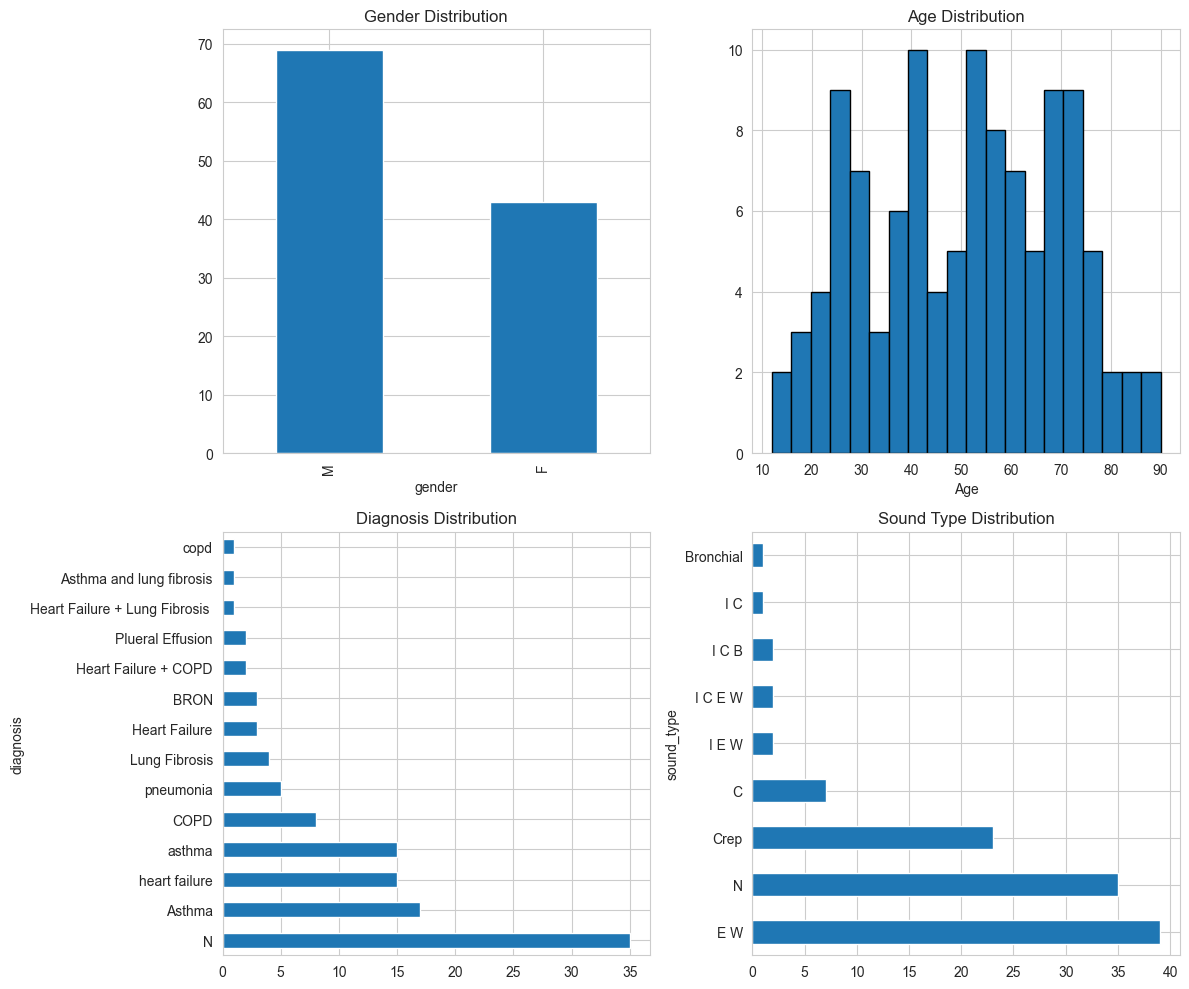

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gender distribution
if "gender" in df.columns:
    df["gender"].value_counts().plot(kind="bar", ax=axes[0, 0])
    axes[0, 0].set_title("Gender Distribution")

# Age distribution
if "age" in df.columns:
    df["age"].dropna().hist(bins=20, ax=axes[0, 1], edgecolor="black")
    axes[0, 1].set_title("Age Distribution")
    axes[0, 1].set_xlabel("Age")

# Diagnosis distribution 
if "diagnosis" in df.columns:
    df["diagnosis"].value_counts().plot(kind="barh", ax=axes[1, 0])
    axes[1, 0].set_title("Diagnosis Distribution")

# Sound type distribution
if "sound_type" in df.columns:
    df["sound_type"].value_counts().head(10).plot(kind="barh", ax=axes[1, 1])
    axes[1, 1].set_title("Sound Type Distribution")

plt.tight_layout()
plt.show()

In [74]:
print(df['diagnosis'].unique())

['Asthma' 'Heart Failure + Lung Fibrosis ' 'Heart Failure + COPD'
 'Plueral Effusion' 'Heart Failure' 'heart failure' 'COPD' 'pneumonia'
 'Asthma and lung fibrosis' 'BRON' 'Lung Fibrosis' 'copd' 'asthma' 'N']


In [75]:
# Classify each recording as heart disease or lung disease based on Diagnosis
heart_diagnoses = ['Heart Failure', 'heart failure', 'Heart Failure + COPD', 
                   'Heart Failure + Lung Fibrosis', 'Heart Failure + Lung Fibrosis ']
lung_diagnoses = ['Asthma', 'asthma', 'COPD', 'copd', 'pneumonia', 'Lung Fibrosis', 
                  'Asthma and lung fibrosis', 'BRON', 'Plueral Effusion']

def get_disease_class(diagnosis):
    d = str(diagnosis).strip()
    if d in heart_diagnoses:
        return 'heart disease'
    if d in lung_diagnoses:
        return 'lung disease'
    return 'normal'  

df['disease_class'] = df['diagnosis'].apply(get_disease_class)
print(df['disease_class'].value_counts())
df.head(10)

disease_class
lung disease     56
normal           35
heart disease    21
Name: count, dtype: int64


,age,gender,location,sound_type,diagnosis,disease_class
0,70,M,P L L,I E W,Asthma,lung disease
1,52,F,P L L,E W,Asthma,lung disease
2,50,F,P L L,I E W,Asthma,lung disease
3,72,F,P R L,I C,Heart Failure + Lung Fibrosis,heart disease
4,71,M,P R L,I C E W,Heart Failure + COPD,heart disease
5,81,M,P R L,I C B,Plueral Effusion,lung disease
6,65,M,P R L,I C E W,Heart Failure + COPD,heart disease
7,70,M,P L L,I C B,Plueral Effusion,lung disease
8,59,M,P R L,E W,Asthma,lung disease
9,59,M,P R U,E W,Asthma,lung disease


In [76]:
print(df['sound_type'].unique())

['I E W' 'E W' 'I C' 'I C E W' 'I C B' 'C' 'Crep' 'N' 'Bronchial']


In [77]:
df = df[~df['sound_type'].str.contains('Bronchial', case=False, na=False)]

def map_sound_types(sound):
    labels = []
    
    if 'W' in sound:
        labels.append('Wheezes')
        
    if 'C' in sound:
        labels.append('Crackles')

    if 'Crep' in sound:
        labels.append('Crepitations')
    
    if 'N' in sound:
        labels.append('Normal')
        
    return labels

df['sound_class'] = df['sound_type'].apply(map_sound_types)

In [78]:
df_expanded = df.explode('sound_class')
print(df_expanded['sound_class'].unique())
print(df_expanded['sound_class'].value_counts())

['Wheezes' 'Crackles' 'Crepitations' 'Normal']
sound_class
Wheezes         43
Crackles        35
Normal          35
Crepitations    23
Name: count, dtype: int64


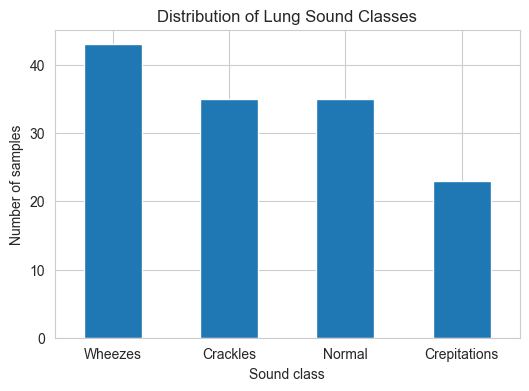

In [79]:
import matplotlib.pyplot as plt

class_counts = df_expanded['sound_class'].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.ylabel('Number of samples')
plt.xlabel('Sound class')
plt.title('Distribution of Lung Sound Classes')
plt.xticks(rotation=0)
plt.show()

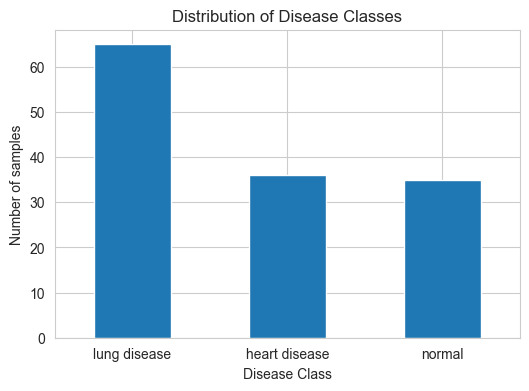

In [83]:
import matplotlib.pyplot as plt

class_counts = df_expanded['disease_class'].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.ylabel('Number of samples')
plt.xlabel('Disease Class')
plt.title('Distribution of Disease Classes')
plt.xticks(rotation=0)
plt.show()

## Audio Files

In [84]:
audio_dir = Path("archive/Audio Files")
audio_files = list(audio_dir.glob("*.wav"))
print(f"Total WAV files: {len(audio_files)}")
print("\nSample filenames:")
for f in audio_files[:5]:
    print(f"  {f.name}")

Total WAV files: 336

Sample filenames:
  BP33_Asthma,E W,P R M,43,F.wav
  DP63_COPD,E W,P R L ,58,F.wav
  EP30_N,N,P R M,18,F.wav
  DP85_N,N,A R U,33,M.wav
  DP71_N,N,P R U,36,M.wav


In [85]:
def parse_audio_filename(filename):
    name = filename.stem  # e.g. BP33_Asthma,E W,P R M,43,F
    filter_type = name[0]  # B, D, or E
    
    parts = name.split("_", 1)
    patient_id = parts[0] if len(parts) > 1 else ""
    rest = parts[1] if len(parts) > 1 else parts[0]

    tokens = [t.strip() for t in rest.split(",")]

    if len(tokens) >= 5:
        return {
            "filter": filter_type,
            "patient_id": patient_id[1:],
            "diagnosis": tokens[0],
            "sound_type": tokens[1],
            "location": tokens[2],
            "age": int(tokens[3]) if tokens[3].isdigit() else None,
            "gender": tokens[4],
            "filename": filename.name
        }
        
    return {"filter": filter_type, "filename": filename.name}

audio_meta = [parse_audio_filename(f) for f in audio_files]
df_audio = pd.DataFrame(audio_meta)
df_audio.head(10)

,filter,patient_id,diagnosis,sound_type,location,age,gender,filename
0,B,P33,Asthma,E W,P R M,43,F,"BP33_Asthma,E W,P R M,43,F.wav"
1,D,P63,COPD,E W,P R L,58,F,"DP63_COPD,E W,P R L ,58,F.wav"
2,E,P30,N,N,P R M,18,F,"EP30_N,N,P R M,18,F.wav"
3,D,P85,N,N,A R U,33,M,"DP85_N,N,A R U,33,M.wav"
4,D,P71,N,N,P R U,36,M,"DP71_N,N,P R U,36,M.wav"
5,B,P52,Lung Fibrosis,Crep,P L L,76,F,"BP52_Lung Fibrosis,Crep,P L L,76,F.wav"
6,B,P75,N,N,P L U,73,F,"BP75_N,N,P L U,73,F.wav"
7,B,P39,heart failure,Crep,P R L,67,M,"BP39_heart failure,Crep,P R L ,67,M.wav"
8,E,P69,pneumonia,Bronchial,P R L,64,M,"EP69_pneumonia,Bronchial,P R L ,64,M.wav"
9,B,P46,asthma,E W,P L U,41,F,"BP46_asthma,E W,P L U,41,F.wav"


In [86]:
# creating sound classes (deleted Bronchial, sounds with both W and C are used in both classes)
df_audio = df_audio[~df_audio['sound_type'].str.contains('Bronchial', case=False, na=False)]

def map_sound_types(sound):
    labels = []
    
    if 'W' in sound:
        labels.append('Wheezes')
    if 'C' in sound:
        labels.append('Crackles')
    if 'Crep' in sound:
        labels.append('Crepitations')
    if 'N' in sound:
        labels.append('Normal')
    return labels

df_audio['sound_class'] = df_audio['sound_type'].apply(map_sound_types)
df_audio_expanded = df_audio.explode("sound_class")
print(df_audio_expanded["sound_class"].value_counts())

sound_class
Wheezes         129
Normal          105
Crackles        105
Crepitations     69
Name: count, dtype: int64


In [87]:
# Classify each recording as heart disease or lung disease based on Diagnosis
heart_diagnoses = ['Heart Failure', 'heart failure', 'Heart Failure + COPD', 
                   'Heart Failure + Lung Fibrosis', 'Heart Failure + Lung Fibrosis ']
lung_diagnoses = ['Asthma', 'asthma', 'COPD', 'copd', 'pneumonia', 'Lung Fibrosis', 
                  'Asthma and lung fibrosis', 'BRON', 'Plueral Effusion']

def get_disease_class(diagnosis):
    d = str(diagnosis).strip()
    if d in heart_diagnoses:
        return 'Heart disease'
    if d in lung_diagnoses:
        return 'Lung disease'
    return 'Normal'  

df_audio_expanded['disease_class'] = df_audio_expanded['diagnosis'].apply(get_disease_class)
print(df_audio_expanded['disease_class'].value_counts())
df_audio_expanded.head(10)

disease_class
Lung disease     195
Heart disease    108
Normal           105
Name: count, dtype: int64


,filter,patient_id,diagnosis,sound_type,location,age,gender,filename,sound_class,disease_class
0,B,P33,Asthma,E W,P R M,43,F,"BP33_Asthma,E W,P R M,43,F.wav",Wheezes,Lung disease
1,D,P63,COPD,E W,P R L,58,F,"DP63_COPD,E W,P R L ,58,F.wav",Wheezes,Lung disease
2,E,P30,N,N,P R M,18,F,"EP30_N,N,P R M,18,F.wav",Normal,Normal
3,D,P85,N,N,A R U,33,M,"DP85_N,N,A R U,33,M.wav",Normal,Normal
4,D,P71,N,N,P R U,36,M,"DP71_N,N,P R U,36,M.wav",Normal,Normal
5,B,P52,Lung Fibrosis,Crep,P L L,76,F,"BP52_Lung Fibrosis,Crep,P L L,76,F.wav",Crackles,Lung disease
5,B,P52,Lung Fibrosis,Crep,P L L,76,F,"BP52_Lung Fibrosis,Crep,P L L,76,F.wav",Crepitations,Lung disease
6,B,P75,N,N,P L U,73,F,"BP75_N,N,P L U,73,F.wav",Normal,Normal
7,B,P39,heart failure,Crep,P R L,67,M,"BP39_heart failure,Crep,P R L ,67,M.wav",Crackles,Heart disease
7,B,P39,heart failure,Crep,P R L,67,M,"BP39_heart failure,Crep,P R L ,67,M.wav",Crepitations,Heart disease


### Saving df as csv file to later use for preprocessing and feature extraction

In [88]:
df_audio_expanded.to_csv("audio_metadata.csv", index=False)

### Plotting waveform and spectrogram

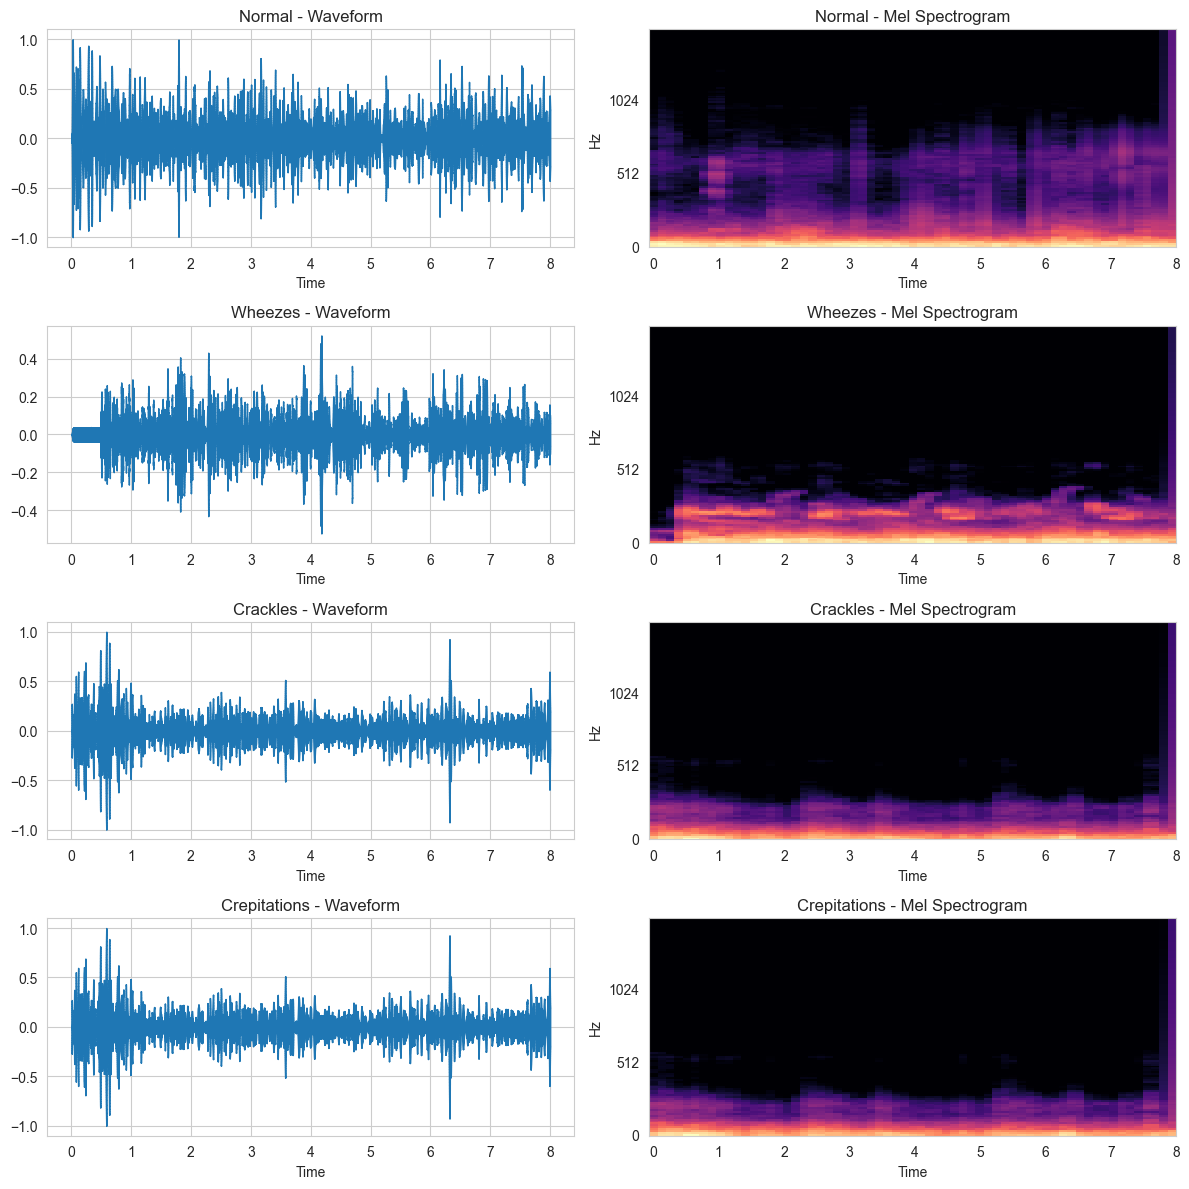

In [90]:
audio_dir = Path("archive/Audio Files")

classes = ["Normal", "Wheezes", "Crackles", "Crepitations"]

fig, axes = plt.subplots(len(classes), 2, figsize=(12, 12))

for i, cls in enumerate(classes):

    # get one example from the class
    row = df_audio_expanded[df_audio_expanded["sound_class"] == cls].iloc[0]
    file_path = audio_dir / row["filename"]

    # load audio
    y, sr = librosa.load(file_path, sr=None)

    # optional: limit to first 8 seconds for cleaner plots
    y = y[:sr*8]

    # waveform 
    librosa.display.waveshow(y, sr=sr, ax=axes[i,0])
    axes[i,0].set_title(f"{cls} - Waveform")

    # spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        ax=axes[i,1]
    )

    axes[i,1].set_title(f"{cls} - Mel Spectrogram")

plt.tight_layout()
plt.show()